## 1) Setup and loading Data
#### First, we import the necessary libraries for data manipulation, text processing, and linguistic analysis.

In [1]:
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt

from nltk.sentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter
from nltk.util import ngrams

# Download required NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('vader_lexicon')
!pip install textblob


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\prith\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\prith\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\prith\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\prith\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [2]:
# Load the dataset
df = pd.read_csv('Mental-Health-Twitter.csv')
df.head()

,Unnamed: 0,post_id,post_created,post_text,user_id,followers,friends,favourites,statuses,retweets,label
0,0,637894677824413696,Sun Aug 30 07:48:37 +0000 2015,It's just over 2 years since I was diagnosed w...,1013187241,84,211,251,837,0,1
1,1,637890384576778240,Sun Aug 30 07:31:33 +0000 2015,"It's Sunday, I need a break, so I'm planning t...",1013187241,84,211,251,837,1,1
2,2,637749345908051968,Sat Aug 29 22:11:07 +0000 2015,Awake but tired. I need to sleep but my brain ...,1013187241,84,211,251,837,0,1
3,3,637696421077123073,Sat Aug 29 18:40:49 +0000 2015,RT @SewHQ: #Retro bears make perfect gifts and...,1013187241,84,211,251,837,2,1
4,4,637696327485366272,Sat Aug 29 18:40:26 +0000 2015,It’s hard to say whether packing lists are mak...,1013187241,84,211,251,837,1,1


## Text Preprocessing
#### In this step, we clean the raw tweet text by converting it to lowercase and removing special characters, numbers, and extra whitespace

In [3]:
def clean_text(text):
    
    text = str(text).lower() 
    text = re.sub(r'[^a-z\s]', '', text)  # Remove punctuation/special characters
    text = re.sub(r'\d+', '', text)       # Remove digits
    text = re.sub(r'\s+', ' ', text)      # Remove extra whitespace
    return text

# Creating a cleaned text column
df['clean_text'] = df['post_text'].apply(clean_text)
df['clean_text'].head(10)

0    its just over years since i was diagnosed with...
1    its sunday i need a break so im planning to sp...
2    awake but tired i need to sleep but my brain h...
3    rt sewhq retro bears make perfect gifts and ar...
4    its hard to say whether packing lists are maki...
5     making packing lists is my new hobby movinghouse
6    at what point does keeping stuff for nostalgic...
7    currently in the findingboxesofrandomshit pack...
8    cant be bothered to cook take away on the way ...
9    rt itventsnews itv releases promo video for th...
Name: clean_text, dtype: object

In [4]:
# Defining stop words (standard English + custom Twitter-specific noise)
nltk_stops = stopwords.words('english')
custom_stops = ['rt', 'im', 'dont', 'amp', 'one', 'like', 'get', 'know', 'time', 'people', 'u']
stop_words = set(nltk_stops + custom_stops)

def remove_stopwords(text):
    tokens = word_tokenize(str(text))
    return [w for w in tokens if w.lower() not in stop_words]

# Tokenize and remove stop words
df['tokens_no_stopwords'] = df['clean_text'].apply(remove_stopwords)
df.head()

,Unnamed: 0,post_id,post_created,post_text,user_id,followers,friends,favourites,statuses,retweets,label,clean_text,tokens_no_stopwords
0,0,637894677824413696,Sun Aug 30 07:48:37 +0000 2015,It's just over 2 years since I was diagnosed w...,1013187241,84,211,251,837,0,1,its just over years since i was diagnosed with...,"[years, since, diagnosed, anxiety, depression,..."
1,1,637890384576778240,Sun Aug 30 07:31:33 +0000 2015,"It's Sunday, I need a break, so I'm planning t...",1013187241,84,211,251,837,1,1,its sunday i need a break so im planning to sp...,"[sunday, need, break, planning, spend, little,..."
2,2,637749345908051968,Sat Aug 29 22:11:07 +0000 2015,Awake but tired. I need to sleep but my brain ...,1013187241,84,211,251,837,0,1,awake but tired i need to sleep but my brain h...,"[awake, tired, need, sleep, brain, ideas]"
3,3,637696421077123073,Sat Aug 29 18:40:49 +0000 2015,RT @SewHQ: #Retro bears make perfect gifts and...,1013187241,84,211,251,837,2,1,rt sewhq retro bears make perfect gifts and ar...,"[sewhq, retro, bears, make, perfect, gifts, gr..."
4,4,637696327485366272,Sat Aug 29 18:40:26 +0000 2015,It’s hard to say whether packing lists are mak...,1013187241,84,211,251,837,1,1,its hard to say whether packing lists are maki...,"[hard, say, whether, packing, lists, making, l..."


# 3) Analysing Text 
### Here we analyze the linguistic differences between depressive (Label 1) and non-depressive (Label 0) posts.

## Word Frequency Analysis

In [5]:
depressive_posts = df[df['label'] == 1]['tokens_no_stopwords']
non_depressive_posts = df[df['label'] == 0]['tokens_no_stopwords']

raw_dep = ' '.join(depressive_posts.astype(str)).lower().split()
raw_ndep = ' '.join(non_depressive_posts.astype(str)).lower().split()

words_dep = [w.strip("[]',") for w in raw_dep]
words_ndep = [w.strip("[]',") for w in raw_ndep]

# 2. Count the words
freq_dep = Counter(words_dep)
freq_ndep = Counter(words_ndep)

# 3. Get the most common words
print("Top 10 Depressive Words:", freq_dep.most_common(10))
print("Top 10 Non-Depressive Words:", freq_ndep.most_common(10))

Top 10 Depressive Words: [('depression', 872), ('misslusyd', 332), ('love', 317), ('treatments', 268), ('good', 246), ('go', 239), ('new', 225), ('got', 223), ('genevieveverso', 220), ('overcome', 219)]
Top 10 Non-Depressive Words: [('trump', 332), ('thank', 324), ('say', 308), ('love', 280), ('yong', 269), ('twitter', 268), ('realdonaldtrump', 258), ('youre', 221), ('following', 212), ('good', 209)]


## Type-Token Ratio (TTR)

In [6]:
def ttr(tokens) :
    types = len(set(tokens))
    total = len(tokens)
    return types / total

print(f"TTR A : {ttr(words_dep):.2f}")
print(f"TTR B : {ttr(words_ndep):.2f}")

TTR A : 0.25
TTR B : 0.28


## Common and Unique Words

In [7]:
common = set(words_dep) & set(words_ndep)
unique_dep = set(words_dep) - set(words_ndep)
unique_ndep = set(words_ndep) - set(words_dep)


## User Characterstics

In [9]:
cols = ['followers', 'friends', 'statuses']
# Top 10 users for label 1 (Depressive)
top_dep_ids = df[df['label'] == 1]['user_id'].value_counts().head(10).index

# Top 10 users for label 0 (Non-Depressive)
top_ndep_ids = df[df['label'] == 0]['user_id'].value_counts().head(10).index

# Creating two separate dataframes
dep_stats = df[df['user_id'].isin(top_dep_ids)][cols].mean()
ndep_stats = df[df['user_id'].isin(top_ndep_ids)][cols].mean()

# Combining them for a side-by-side comparison
final_comparison = pd.DataFrame({'Depressive (Avg)': dep_stats, 'Non-Depressive (Avg)': ndep_stats})
print(final_comparison)

           Depressive (Avg)  Non-Depressive (Avg)
followers        595.875334            978.098626
friends          818.526535            569.098090
statuses       11019.037049          84331.963833


# Findings from analysing text

###  Word Frequency Analysis
####  The 10 most used words represent the existence of a sharp thematic gap between the two groups. The vocabulary of the depressive group is very clinical and self-centered and it is characterized by such terms as depression (872) and treatments (268) meaning that they focus on mental health issues. The non-depressive group, on the contrary, is less internally oriented and more social with numerous references to the terms trump (332) and thank (324). Interestingly, love is present in both lists although it is probably a support-seeking word in one of them and a general feeling in the other.

###  Vocabulary Richness (TTR)
#### The Type Token Ratio (TTR) of depressive posts is 0.25 as compared to 0.28 of non-depressive posts. This reduced ratio of the depressive group means that there is more repetitive use of language. This is often reflected in a mental framework as rumination whereby people become obsessed with a limited number of distressing thoughts or themes; as a result of this they have less varied and more circular vocabulary than their non-depressed peers.

### Common and Unique Words
#### The distinct word formations indicate that there is a language of suffering and a language of everyday life. Depressive group has distinctive terminologies that focus on recovery, struggle and internal conditions. The language used by the non-depressive group is much more diverse, and encompasses politics, the mechanics of social media (such as twitter, following, etc.), and social niceties. This implies that depression can constrict a user in terms of his or her linguistic capability in relation to his or her immediate affective condition.

### User Characteristics & User activity
#### The statistics regarding the 10 most active users indicate that depressive people are much less digital vital. The users who are not depressed update their statuses almost 8 times more (84, 331 vs. 11,019) and do twice as many retweets. They actually have a more average number of friends (818 vs. 569), but since they have much fewer followers and favorites, they might be using the platform to passively consume or view the content instead of two-way active and reciprocal social communication.

# 4) Visualising Data 

## Word Cloud Visualization 

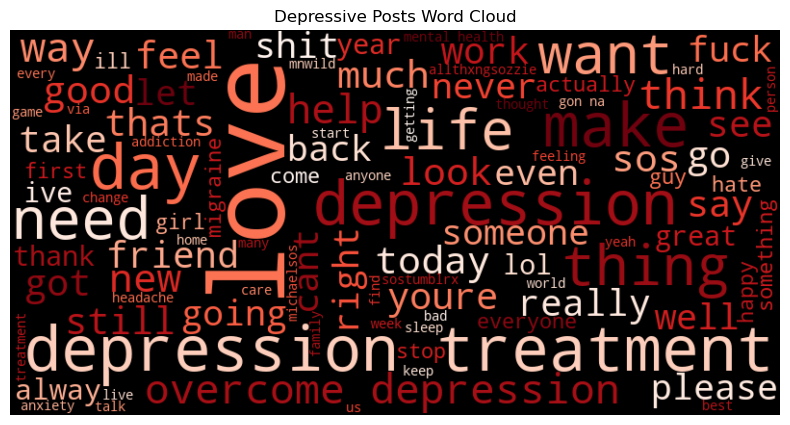

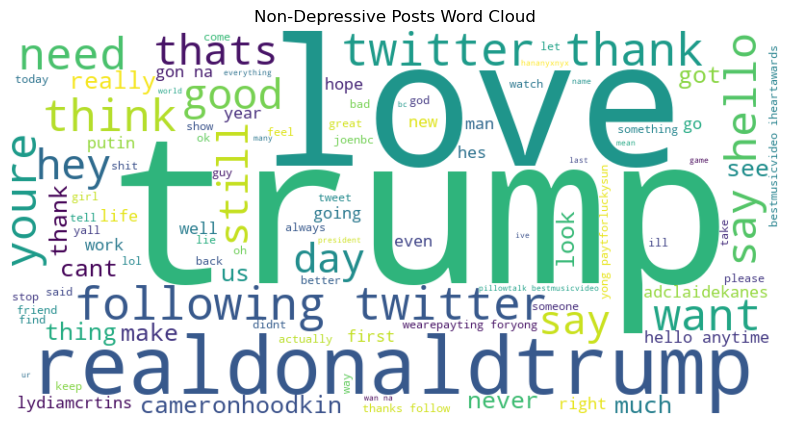

In [10]:
# Conversion of word lists into single strings for WordCloud processing
text_dep = ' '.join(words_dep)
text_ndep = ' '.join(words_ndep)

# --- Depressive Posts Word Cloud (Label = 1) ---
wc_dep = WordCloud(width=800, height=400, 
                   background_color='black',
                   colormap='Reds',
                   max_words=100).generate(text_dep)

plt.figure(figsize=(10, 5))
plt.imshow(wc_dep, interpolation='bilinear')
plt.axis('off')
plt.title('Depressive Posts Word Cloud')
plt.show()


# --- Non-Depressive Posts Word Cloud (Label = 0) ---
wc_ndep = WordCloud(width=800, height=400, 
                    background_color='white', # Matches the slide's example
                    colormap='viridis',       # Matches the slide's example
                    max_words=100).generate(text_ndep)

plt.figure(figsize=(10, 5))
plt.imshow(wc_ndep, interpolation='bilinear')
plt.axis('off')
plt.title('Non-Depressive Posts Word Cloud')
plt.show()


## Sentiment Analysis
### Using VADER sentiment analysis to compare the two groups

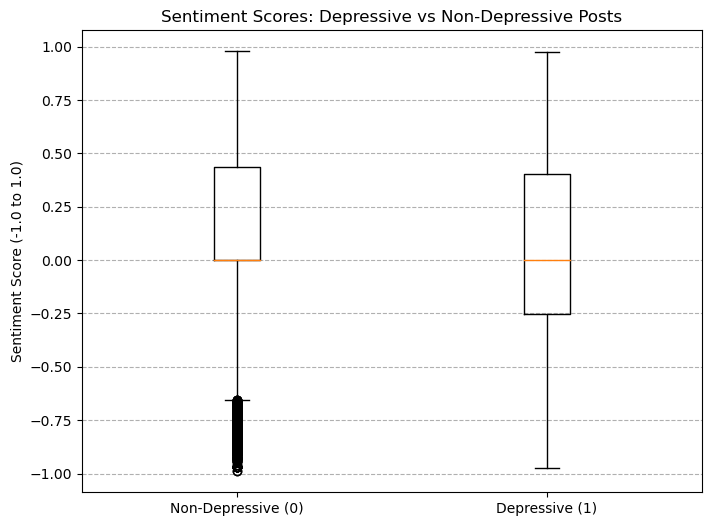

In [11]:
#Set up 
sia = SentimentIntensityAnalyzer()

# Calculate compound sentiment scores across the dataset

def get_sentiment(text):
    return sia.polarity_scores(str(text))['compound']   

# 4. Applying the function to the dataframe
df['sentiment_score'] = df['post_text'].apply(get_sentiment)

# 5. Spliting the scores into two lists for the boxplot
dep_scores = df[df['label'] == 1]['sentiment_score']
ndep_scores = df[df['label'] == 0]['sentiment_score']


# --- Sentiment Distribution Box Plot ---
plt.figure(figsize=(8, 6))
plt.boxplot([ndep_scores, dep_scores], labels=['Non-Depressive (0)', 'Depressive (1)'])


plt.title('Sentiment Scores: Depressive vs Non-Depressive Posts')
plt.ylabel('Sentiment Score (-1.0 to 1.0)')
plt.grid(True, axis='y', linestyle='--')
plt.show()

## User Characterstics

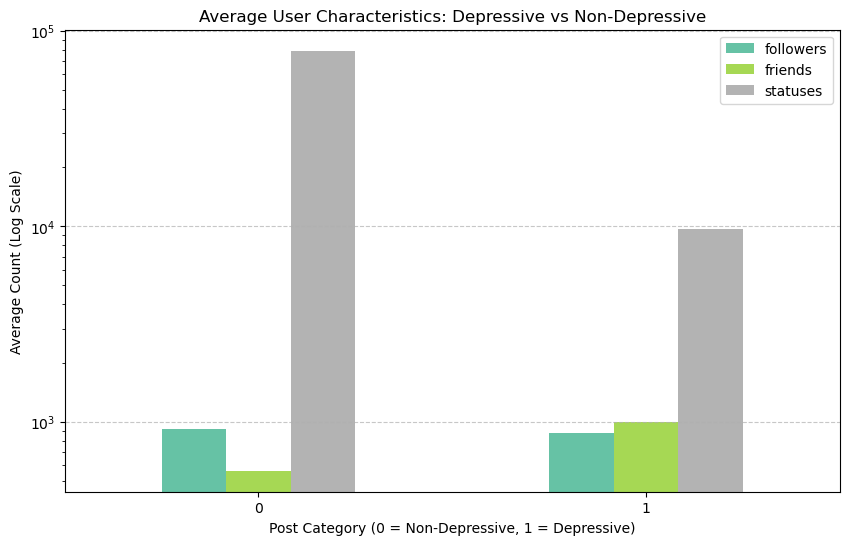

In [12]:
# Identifing relevant user metrics for comparison
cols_to_plot = ['followers', 'friends', 'statuses']
avg_characteristics = df.groupby('label')[cols_to_plot].mean()

# --- Grouped Bar Chart of User Metrics ---
ax = avg_characteristics.plot(kind='bar', figsize=(10, 6), logy=True, colormap='Set2')

plt.title('Average User Characteristics: Depressive vs Non-Depressive')
plt.xlabel('Post Category (0 = Non-Depressive, 1 = Depressive)')
plt.ylabel('Average Count (Log Scale)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# Findings

### Word Cloud Visualization
#### The word cloud visualisations show a distinct thematic difference between the two groups of study. The cloud of the depressive group is overloaded with clinical and urgent vocabulary like depression, help, need, treatment, which implies that it is a type of communication based on the inner conflict with and a request to assist. Comparatively, the non-depressive cloud is one that represents an externally focused and socially dynamic lexicon that has featured public figures and platform-specific words such as "trump," "realdonaldtrump," and twitter. Although the word love is found in both datasets, the fact that it is closer to the words such as help in the depressive group compared to thank in the non-depressive group demonstrates that the same feeling is perceived through dissimilar emotional lenses.

### Sentiment Analysis
#### According to the VADER sentiment distribution shown in the box plot, the depressive posts tend to have a lower emotional weight as compared to non-depressive posts. Although the two types have an entire spectrum of sentiment ranging between -1.0 and 1.0, the non-depressive group has a higher median score as well as a more concentrated positive sentiment. The score of the depressive group is more evenly spread to the side of the scale that is negative, which proves that their language preferences are associated with a more depressive state of emotions that is consistent. This change in the inter quartile range is effectively visualised to represent the emotive weight that makes the two kinds of user posts stand out.

### User Characteristics
#### The log scale comparison of average user measures indicates that there is an incredible gap between the total platform use. The most meaningful observation is the status count, on which non-depressed users post with nearly a tenfold frequency as the depressive group, with average numbers of  $10^5$ compared to $10^4$. Although the number of followers and friends is comparatively close between the two labels, the much lower status and the number of favour in the depressed group indicates a tendency of being socially withdrawn or a mere user. These results indicate that the depressive users have an equivalent size social network, but with extremely low levels of digital vitality, and significantly reduced the interaction with the rest of the community.


# Visualising N-grams

## N-gram Generation and Top n grams

In [13]:
# Creating a function to generate and count N-grams
def get_top_ngrams(word_list, n, top_k=5):
    
    n_grams = ngrams(word_list, n)
    n_gram_freq = Counter(n_grams)
    return n_gram_freq.most_common(top_k)


# Top 5 for Depressive Posts (Label 1)

print("DEPRESSIVE POSTS TOP 5")
# Unigrams (n=1)
print("Unigrams:", get_top_ngrams(words_dep, 1))
# Bigrams (n=2)
print("Bigrams:", get_top_ngrams(words_dep, 2))
# Trigrams (n=3)
print("Trigrams:", get_top_ngrams(words_dep, 3))
# Quad-grams (n=4)
print("Quad-grams:", get_top_ngrams(words_dep, 4))

print("\n")


# Top 5 for Non-Depressive Posts (Label 0)

print(" NON-DEPRESSIVE POSTS TOP 5 ")
# Unigrams (n=1)
print("Unigrams:", get_top_ngrams(words_ndep, 1))
# Bigrams (n=2)
print("Bigrams:", get_top_ngrams(words_ndep, 2))
# Trigrams (n=3)
print("Trigrams:", get_top_ngrams(words_ndep, 3))
# Quad-grams (n=4)
print("Quad-grams:", get_top_ngrams(words_ndep, 4))

DEPRESSIVE POSTS TOP 5
Unigrams: [(('depression',), 872), (('misslusyd',), 332), (('love',), 317), (('treatments',), 268), (('good',), 246)]
Bigrams: [(('depression', 'treatments'), 257), (('overcome', 'depression'), 199), (('gon', 'na'), 88), (('mental', 'health'), 70), (('wan', 'na'), 67)]
Trigrams: [(('thefuxedos', 'genevieveverso', 'tauril'), 27), (('team', 'beachbodys', 'supergym'), 23), (('beachbodys', 'supergym', 'join'), 23), (('supergym', 'join', 'go'), 23), (('circles', 'end', 'depression'), 23)]
Quad-grams: [(('team', 'beachbodys', 'supergym', 'join'), 23), (('beachbodys', 'supergym', 'join', 'go'), 23), (('circles', 'end', 'depression', 'therapy'), 23), (('officialncfc', 'may', 'th', 'autism'), 19), (('lizsmith', 'thefuxedos', 'genevieveverso', 'tauril'), 19)]


 NON-DEPRESSIVE POSTS TOP 5 
Unigrams: [(('trump',), 332), (('thank',), 324), (('say',), 308), (('love',), 280), (('yong',), 269)]
Bigrams: [(('following', 'twitter'), 204), (('twitter', 'thank'), 204), (('say', 'he

## Comparative Visualisation

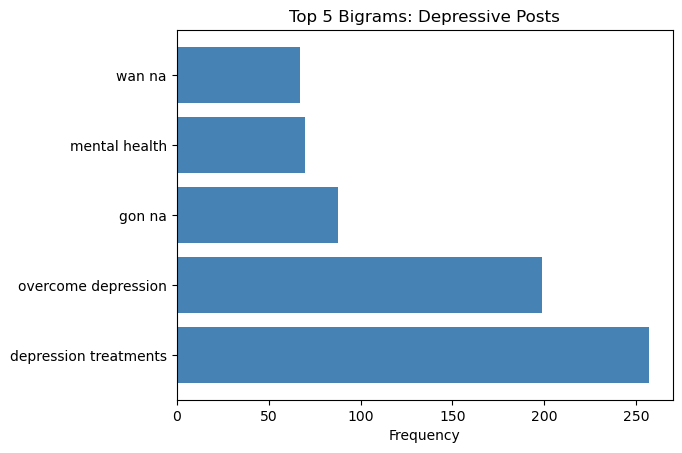

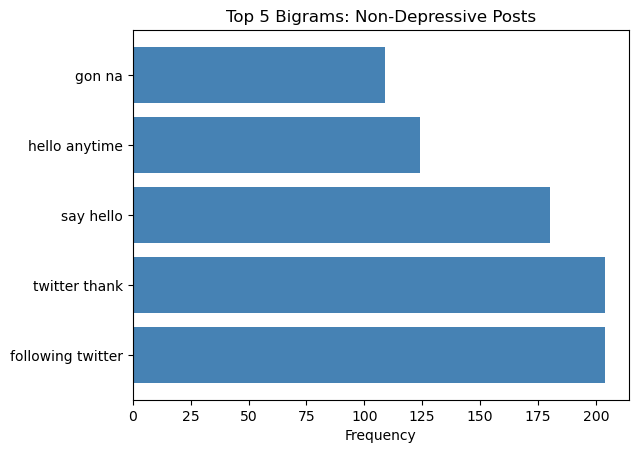

In [14]:
# DEPRESSIVE POSTS BIGRAMS
bigrams_dep = Counter(ngrams(words_dep, 2))
top5_dep = bigrams_dep.most_common(5)

labels_dep = [' '.join(b) for b, c in top5_dep]
counts_dep = [c for b, c in top5_dep]

plt.barh(labels_dep, counts_dep, color='steelblue')
plt.xlabel('Frequency')
plt.title('Top 5 Bigrams: Depressive Posts')
plt.show()

# 2. NON-DEPRESSIVE POSTS BIGRAMS
bigrams_ndep = Counter(ngrams(words_ndep, 2))
top5_ndep = bigrams_ndep.most_common(5)

labels_ndep = [' '.join(b) for b, c in top5_ndep]
counts_ndep = [c for b, c in top5_ndep]

plt.barh(labels_ndep, counts_ndep, color='steelblue')
plt.xlabel('Frequency')
plt.title('Top 5 Bigrams: Non-Depressive Posts')
plt.show()


## Temporal Analysis

C:\Users\prith\AppData\Local\Temp\ipykernel_16164\4030058824.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['post_created'])
C:\Users\prith\AppData\Local\Temp\ipykernel_16164\4030058824.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['month'] = df['date'].dt.to_period('M')


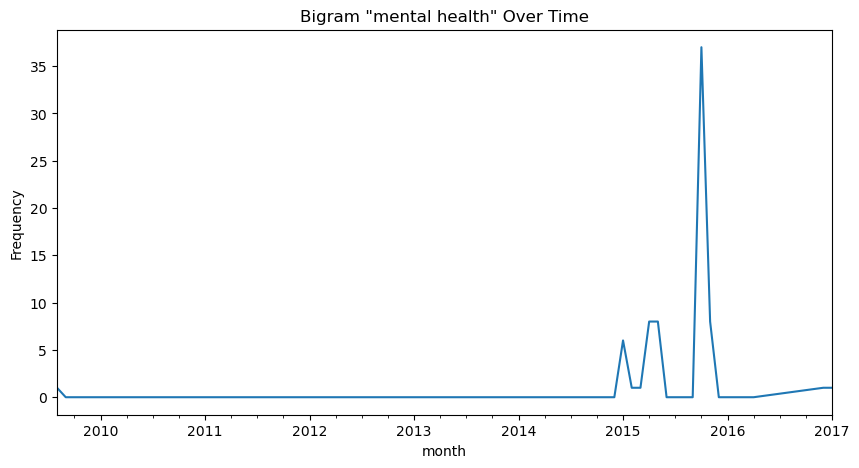

In [15]:
# Parse dates and create a monthly period column
df['date'] = pd.to_datetime(df['post_created'])
df['month'] = df['date'].dt.to_period('M')

# Counting a specific bigram over time 
def count_bigram(text, target):
    
    tokens = str(text).lower().split()
    bgs = list(ngrams(tokens, 2))
    return bgs.count(target)

# Appling the function using a lambda 
df['mental_health'] = df['clean_text'].apply(
    lambda x: count_bigram(x, ('mental', 'health'))
)

# Grouping by month and plotting
monthly = df.groupby('month')['mental_health'].sum()
monthly.plot(kind='line', 
             title='Bigram "mental health" Over Time',
             figsize=(10, 5)) # Added figsize just so it isn't too squished

plt.ylabel('Frequency')
plt.show()

# Findings

## Ngram Generation and Top n grams

#### The n-gram analysis determines linguistic clusters most commonly used and gives a detailed view of the phrases that characterize each cluster. Among the depressive group (Label 1), clinical and recovery-related terms dominate a lot among unigrams and bigrams, i.e. depression (872), depression treatments (257), and overcome depression (199). On the other hand, the non-depressive (Label 0) group is preoccupied with social and political conversation, with phrases of top frequency, such as trumps (332), bigrams, such as following twitter (204) and say hello (180). It means that one category of users devotes time to the platform to manage individual health whereas the other one dedicates their time to the external socialization and news on the platform.

## Comparative Visualisation

#### The bar graphs of the bigrams compared show the sharp difference between the usage of the language in terms of bigrams between the two categories. The most recognizable terms used by the depressive group such as depression treatments, overcome depression, and mental health refer to one particular focus on their situation. Conversely, the non-depressive group reveals the bigrams of the non-depressive group like twitter thank, say hello, and hello anytime which illustrate a highly communicative and interactive style. This visualisation confirms that, the linguistic divide is not merely about each word in itself but whole phrases that portend varying degrees of social interaction as opposed to internalised dissonance.

## Temporal Analysis

#### The temporal study of the bigram "mental health" shows how the use of language changes over time. According to the line chart, during most of the years between 2010 and 2015, the phrase was hardly utilized. Nevertheless, there was a sudden, huge spike in the end of 2015, as the number of instances increased to approximately 40 per month. It implies that the typical language of these communities does not remain constant; it may be dramatically affected by particular events, awareness campaigns, or changes in the general digital discourse of mental health.

# Reflecting on the Process


## Technical Problems and Solutions.

#### The project had a number of hurdles with data preprocessing. At first, I came up with a list of tokenized items, which was hard to categorize by depressive and non-depressive posts. To address this, I inserted a column for tokenized text into the dataframe to be filtered by label with ease. Another issue was "text noise." Previously word clouds were plagued with twitter specific terms such as "rt" and "amp" or tokens like "im" which bypasses the general NLTK filters. Another problem that I faced was with empty strings (), which were shown many times when I was attempting to find top words. To this end, I adopted a custom stopword list and strip() to go through the tokens to ensure they are cleaned appropriately.

## NLP Insights

#### When NLP techniques were applied to mental health data, it was found that different techniques had varied effectiveness:

#### Word Frequency: Although this is helpful in determining the basic themes such as depression or treatment, single word counts tend to be out of context.
#### N-grams: They allowed gaining a deeper understanding of the linguistic patterns, including phrases such as mental health or feel like, which give a better understanding of the internal condition of the user when not separated by words.
#### Sentiment Analysis: Tools like VADER, are best suited to social media as they consider the strength of emotive words, and as such, the negative tilt of depressive posts can be quantified.


## Findings Interpretation
#### The comparison of the behavioural differences was evident:
##### Engagement: The non-depressive power users were enormous broadcasters with a mean of above 84,331 statuses and 978 followers.
##### Isolation: The depressive users demonstrated more shares in passive consuming, as they had received more friends (818 friends) than they had given (595 followers) and there was much less posting.

## Ethical Considerations
#### There is a need to be cautious about privacy and anonymity in the analysis as there is a likelihood that users would not agree to have their mental condition detected automatically. The possibility of biased data sets also exists since the social media trends do not reflect the whole population. More importantly, automated detection is not a tool to do away with, it should complement human control and professional judgment of the clinical situation.